# Wattnet.eu data pull and quick visuals
## Ted Scott
(2026-06-15)

## from Mohammad:
"Looking at the AWS EU regions (https://aws.amazon.com/about-aws/global-infrastructure/regions_az/), in addition to Ireland the following regions seem interesting (older, more established regions):

- Frankfurt (major hub in Germany)
- Paris (France has lots of green nuclear energy, so this is a good data point)
- London (physically close to Ireland, so enables low-latency workload shifting if carbon intensity lower)
- Stockholm (low carbon intensity historically)
- Ireland

5 regions total would be enough for our analysis."

---

Based on the pre-print (https://zenodo.org/records/17404776) and the github (https://github.com/wattnet/wattnet-data/blob/main/zones/entsoe_full_zones.yaml) these are those 5 zones
- DE : Germany
- FR : France
- GB : Great Britain
- SE3 : region of Sweden with Stockholm
- IE : Ireland

Answers to Mohammad's other questions:
1. Definition of 'footprint' - I am pulling the "operational" '*global footprint*' which accounts for the carbon intensity of all electricity generation imported and internally generated, and looks to be a **15-min average** based on real-time data (from each energy source used multiplied by a carbon intensity factor in their paper or on their github at https://github.com/wattnet/wattnet-data/blob/main/footprint/Carbon.yaml)
2. Will pull both raw json and parsed data saved as CSV files for each country/region - these are gathered using the page at https://api.wattnet.eu/v1/docs#/Environmental%20Metrics/get_footprints_footprints_get - could not seem to get authentication and API token via their request page so using this "demo" page for their API was a workaround. Maybe someone else will have better luck with the API key request page: https://api.wattnet.eu/token-request/
3. there aren't clear terms of service but they assert this is for researchers and developers (checked https://api.wattnet.eu/v1/docs) and they use the term "open data"

In [55]:
import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns

# ***************

# Germany
## https://api.wattnet.eu/v1/footprints?zone=DE&footprint_type=carbon&scope=operational&start=2026-01-01&end=2026-06-15&aggregate=false&use_global=true

In [18]:
filename = '../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_DE_raw_operational_footprint.json'

In [19]:
with open(filename, "r") as read_it:
     data = json.load(read_it)

In [20]:
# Normalize the data
normalized_df = pd.json_normalize(data[0]['series'][0], 'values')

# Display the DataFrame
normalized_df.reset_index(inplace=True, drop=True)
# rename columns
normalized_df.columns = ['datetime','footprint (gCO2/kWh)']
df_footprint = normalized_df
df_footprint['datetime'] = pd.to_datetime(df_footprint['datetime']).dt.tz_localize(None)
df_footprint['time'] = df_footprint['datetime'].dt.time
df_footprint.info()

<class 'pandas.DataFrame'>
RangeIndex: 15636 entries, 0 to 15635
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              15636 non-null  datetime64[us]
 1   footprint (gCO2/kWh)  15636 non-null  float64       
 2   time                  15636 non-null  object        
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 366.6+ KB


In [21]:
df_footprint.head()

,datetime,footprint (gCO2/kWh),time
0,2026-01-01 00:00:00,218.35,00:00:00
1,2026-01-01 00:15:00,215.18,00:15:00
2,2026-01-01 00:30:00,213.01,00:30:00
3,2026-01-01 00:45:00,212.19,00:45:00
4,2026-01-01 01:00:00,206.45,01:00:00


Text(0.5, 0, 'time (15 min increments)')

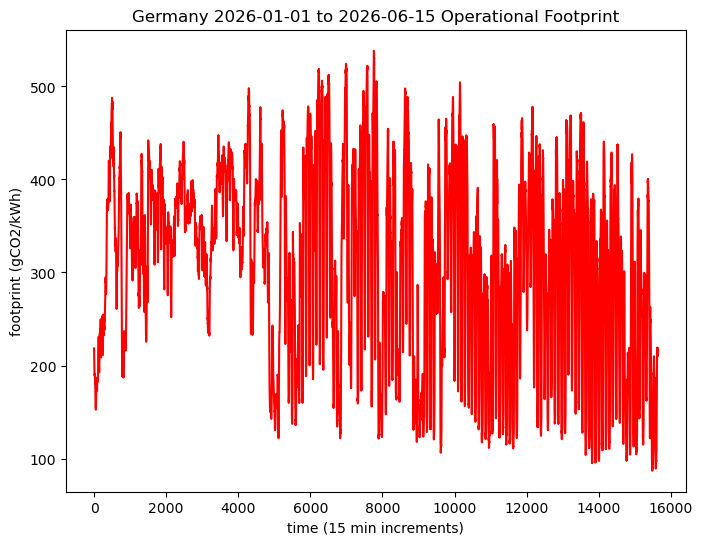

In [22]:
# plot the day of load
plt.figure(figsize=(8,6))
sns.lineplot(data=df_footprint, x=df_footprint.index, y='footprint (gCO2/kWh)', color='red')
plt.title("Germany 2026-01-01 to 2026-06-15 Operational Footprint")
plt.xlabel('time (15 min increments)')

In [23]:
df_footprint.to_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_DE_operational_footprint.csv', index=False)

In [57]:
df_DE = pd.read_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_DE_operational_footprint.csv')

# France
## https://api.wattnet.eu/v1/footprints?zone=FR&footprint_type=carbon&scope=operational&start=2026-01-01&end=2026-06-15&aggregate=false&use_global=true

In [24]:
filename = '../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_FR_raw_operational_footprint.json'

In [25]:
with open(filename, "r") as read_it:
     data = json.load(read_it)

In [30]:
# France data had a portion of the early json marked as zone_status="preview" which we need to skip 
#data[0]['series'][1]['values']
# updated below to reflect using index 1 for series

In [31]:
# Normalize the data
normalized_df = pd.json_normalize(data[0]['series'][1], 'values')

# Display the DataFrame
normalized_df.reset_index(inplace=True, drop=True)
# rename columns
normalized_df.columns = ['datetime','footprint (gCO2/kWh)']
df_footprint = normalized_df
df_footprint['datetime'] = pd.to_datetime(df_footprint['datetime']).dt.tz_localize(None)
df_footprint['time'] = df_footprint['datetime'].dt.time
df_footprint.info()

<class 'pandas.DataFrame'>
RangeIndex: 15701 entries, 0 to 15700
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              15701 non-null  datetime64[us]
 1   footprint (gCO2/kWh)  15701 non-null  float64       
 2   time                  15701 non-null  object        
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 368.1+ KB


In [32]:
df_footprint.head()

,datetime,footprint (gCO2/kWh),time
0,2026-01-02 01:45:00,26.99,01:45:00
1,2026-01-02 02:00:00,28.15,02:00:00
2,2026-01-02 02:15:00,28.44,02:15:00
3,2026-01-02 02:30:00,28.30,02:30:00
4,2026-01-02 02:45:00,27.36,02:45:00


Text(0.5, 0, 'time (15 min increments)')

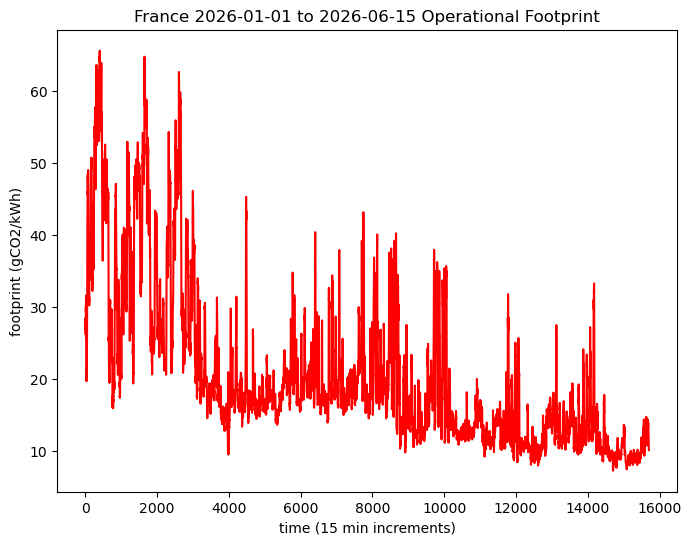

In [33]:
# plot the day of load
plt.figure(figsize=(8,6))
sns.lineplot(data=df_footprint, x=df_footprint.index, y='footprint (gCO2/kWh)', color='red')
plt.title("France 2026-01-01 to 2026-06-15 Operational Footprint")
plt.xlabel('time (15 min increments)')

In [34]:
df_footprint.to_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_FR_operational_footprint.csv', index=False)

In [58]:
df_FR = pd.read_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_FR_operational_footprint.csv')

# Great Britain (incl Northern Ireland)
## https://api.wattnet.eu/v1/footprints?zone=GB&footprint_type=carbon&scope=operational&start=2026-01-01&end=2026-06-15&aggregate=false&use_global=true

In [35]:
filename = '../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_GB_raw_operational_footprint.json'

In [36]:
with open(filename, "r") as read_it:
     data = json.load(read_it)

In [30]:
# GB data does start with index=0 on series

In [37]:
# Normalize the data
normalized_df = pd.json_normalize(data[0]['series'][0], 'values')

# Display the DataFrame
normalized_df.reset_index(inplace=True, drop=True)
# rename columns
normalized_df.columns = ['datetime','footprint (gCO2/kWh)']
df_footprint = normalized_df
df_footprint['datetime'] = pd.to_datetime(df_footprint['datetime']).dt.tz_localize(None)
df_footprint['time'] = df_footprint['datetime'].dt.time
df_footprint.info()

<class 'pandas.DataFrame'>
RangeIndex: 15125 entries, 0 to 15124
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              15125 non-null  datetime64[us]
 1   footprint (gCO2/kWh)  15125 non-null  float64       
 2   time                  15125 non-null  object        
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 354.6+ KB


In [38]:
df_footprint.head()

,datetime,footprint (gCO2/kWh),time
0,2026-01-01 00:00:00,141.19,00:00:00
1,2026-01-01 00:15:00,141.36,00:15:00
2,2026-01-01 00:30:00,142.40,00:30:00
3,2026-01-01 00:45:00,142.34,00:45:00
4,2026-01-01 01:00:00,146.68,01:00:00


Text(0.5, 0, 'time (15 min increments)')

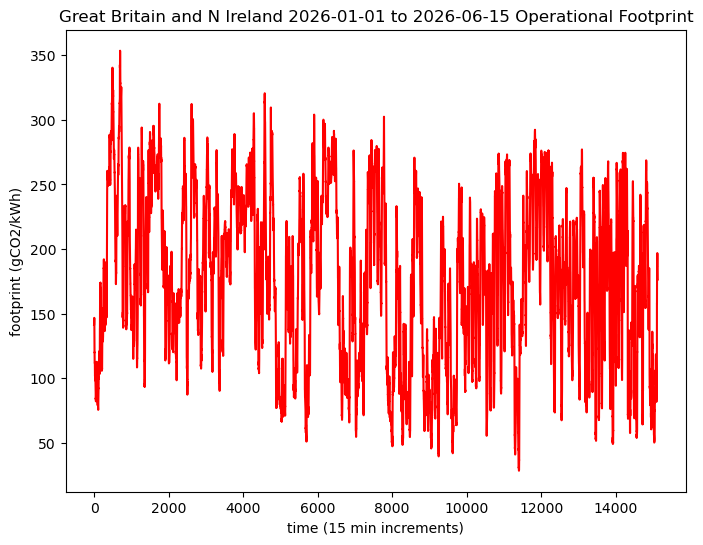

In [40]:
# plot the day of load
plt.figure(figsize=(8,6))
sns.lineplot(data=df_footprint, x=df_footprint.index, y='footprint (gCO2/kWh)', color='red')
plt.title("Great Britain and N Ireland 2026-01-01 to 2026-06-15 Operational Footprint")
plt.xlabel('time (15 min increments)')

In [41]:
df_footprint.to_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_GB_operational_footprint.csv', index=False)

In [59]:
df_GB = pd.read_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_GB_operational_footprint.csv')

# Sweden region SE3 which includes Stockholm
## https://api.wattnet.eu/v1/footprints?zone=SE3&footprint_type=carbon&scope=operational&start=2026-01-01&end=2026-06-15&aggregate=false&use_global=true

In [42]:
filename = '../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_SE3_raw_operational_footprint.json'

In [43]:
with open(filename, "r") as read_it:
     data = json.load(read_it)

In [30]:
# SE3 data does start with index=0 on series

In [44]:
# Normalize the data
normalized_df = pd.json_normalize(data[0]['series'][0], 'values')

# Display the DataFrame
normalized_df.reset_index(inplace=True, drop=True)
# rename columns
normalized_df.columns = ['datetime','footprint (gCO2/kWh)']
df_footprint = normalized_df
df_footprint['datetime'] = pd.to_datetime(df_footprint['datetime']).dt.tz_localize(None)
df_footprint['time'] = df_footprint['datetime'].dt.time
df_footprint.info()

<class 'pandas.DataFrame'>
RangeIndex: 15802 entries, 0 to 15801
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              15802 non-null  datetime64[us]
 1   footprint (gCO2/kWh)  15802 non-null  float64       
 2   time                  15802 non-null  object        
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 370.5+ KB


In [45]:
df_footprint.head()

,datetime,footprint (gCO2/kWh),time
0,2026-01-01 00:00:00,13.45,00:00:00
1,2026-01-01 00:15:00,13.30,00:15:00
2,2026-01-01 00:30:00,13.40,00:30:00
3,2026-01-01 00:45:00,13.47,00:45:00
4,2026-01-01 01:00:00,14.51,01:00:00


Text(0.5, 0, 'time (15 min increments)')

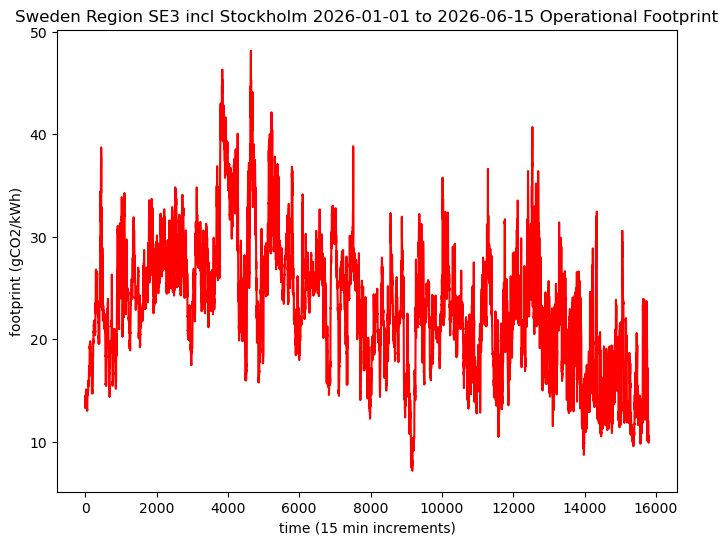

In [46]:
# plot the day of load
plt.figure(figsize=(8,6))
sns.lineplot(data=df_footprint, x=df_footprint.index, y='footprint (gCO2/kWh)', color='red')
plt.title("Sweden Region SE3 incl Stockholm 2026-01-01 to 2026-06-15 Operational Footprint")
plt.xlabel('time (15 min increments)')

In [47]:
df_footprint.to_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_SE3_operational_footprint.csv', index=False)

In [60]:
df_SE3 = pd.read_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_SE3_operational_footprint.csv')

# Ireland
## https://api.wattnet.eu/v1/footprints?zone=IE&footprint_type=carbon&scope=operational&start=2026-01-01&end=2026-06-15&aggregate=false&use_global=true

In [48]:
filename = '../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_IE_raw_operational_footprint.json'

In [49]:
with open(filename, "r") as read_it:
     data = json.load(read_it)

In [50]:
# IE data does start with index=0 on series

In [51]:
# Normalize the data
normalized_df = pd.json_normalize(data[0]['series'][0], 'values')

# Display the DataFrame
normalized_df.reset_index(inplace=True, drop=True)
# rename columns
normalized_df.columns = ['datetime','footprint (gCO2/kWh)']
df_footprint = normalized_df
df_footprint['datetime'] = pd.to_datetime(df_footprint['datetime']).dt.tz_localize(None)
df_footprint['time'] = df_footprint['datetime'].dt.time
df_footprint.info()

<class 'pandas.DataFrame'>
RangeIndex: 12577 entries, 0 to 12576
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              12577 non-null  datetime64[us]
 1   footprint (gCO2/kWh)  12577 non-null  float64       
 2   time                  12577 non-null  object        
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 294.9+ KB


In [52]:
df_footprint.head()

,datetime,footprint (gCO2/kWh),time
0,2026-01-01 00:00:00,157.22,00:00:00
1,2026-01-01 00:15:00,157.27,00:15:00
2,2026-01-01 00:30:00,151.79,00:30:00
3,2026-01-01 00:45:00,151.77,00:45:00
4,2026-01-01 01:00:00,159.05,01:00:00


Text(0.5, 0, 'time (15 min increments)')

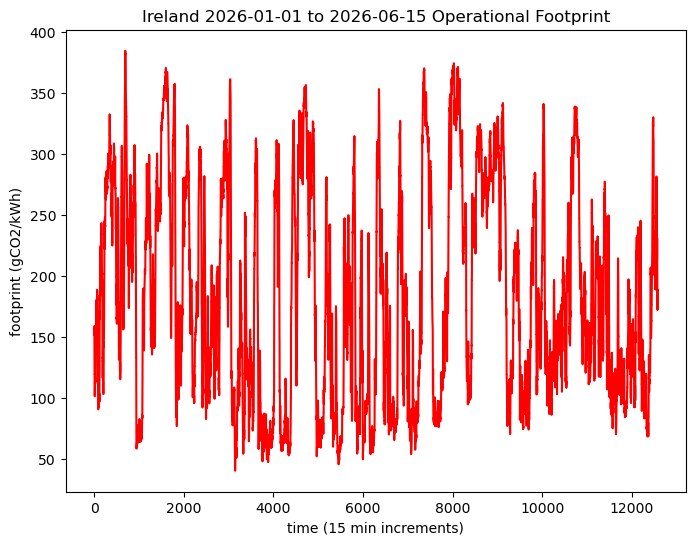

In [53]:
# plot the day of load
plt.figure(figsize=(8,6))
sns.lineplot(data=df_footprint, x=df_footprint.index, y='footprint (gCO2/kWh)', color='red')
plt.title("Ireland 2026-01-01 to 2026-06-15 Operational Footprint")
plt.xlabel('time (15 min increments)')

In [54]:
df_footprint.to_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_IE_operational_footprint.csv', index=False)

In [70]:
df_IE = pd.read_csv('../E2EGHG/wattnet-data/ForMohammad/2026-01-01_2026-06-15_IE_operational_footprint.csv')

## Plot of all 5 regions operational footprint time series

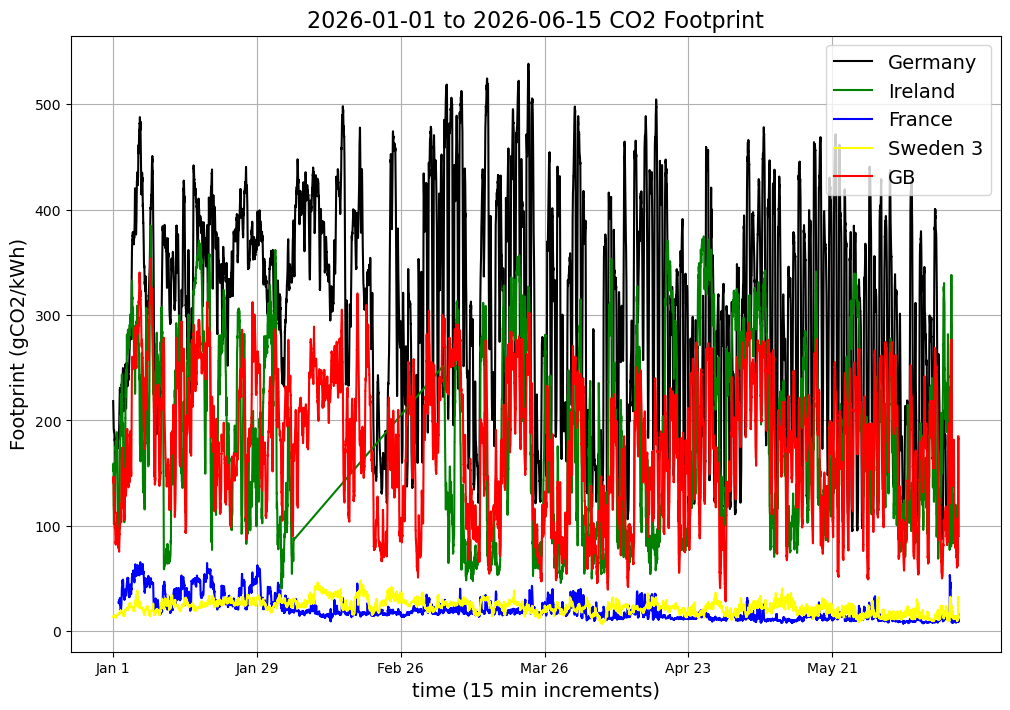

CPU times: user 7.47 s, sys: 113 ms, total: 7.59 s
Wall time: 7.58 s


In [86]:
%%time
# combine into single plot
# help for legend from https://stackoverflow.com/questions/5484922/secondary-axis-with-twinx-how-to-add-to-legend

fig, ax1 = plt.subplots(figsize=(12,8)) # initializes figure and plots

sns.lineplot(data=df_DE, x='datetime', y='footprint (gCO2/kWh)', color='black', ax=ax1, label='Germany')
sns.lineplot(data=df_IE, x='datetime', y='footprint (gCO2/kWh)', color='green', ax=ax1, label='Ireland')
sns.lineplot(data=df_FR, x='datetime', y='footprint (gCO2/kWh)', color='blue', ax=ax1, label='France')
sns.lineplot(data=df_SE3, x='datetime', y='footprint (gCO2/kWh)', color='yellow', ax=ax1, label='Sweden 3')
sns.lineplot(data=df_GB, x='datetime', y='footprint (gCO2/kWh)', color='red', ax=ax1, label='GB')


ax1.legend(fontsize=14)
ax1.grid()

ax1.set_xlabel('time (15 min increments)', fontsize=14)
ax1.set_ylabel('Footprint (gCO2/kWh)', fontsize=14)

ax1.set_xticks(np.arange(0,(365/2-15)*96,96*28))
#plt.xticks(rotation='vertical')
ax1.set_xticklabels(['Jan 1', 'Jan 29', 'Feb 26', 'Mar 26', 'Apr 23','May 21'])
# plt.legend()
plt.title("2026-01-01 to 2026-06-15 CO2 Footprint", fontsize=16)

plt.show()

## * Note that there is a roughly one month gap in the Ireland footprint data - more obvious with a scatterplot below

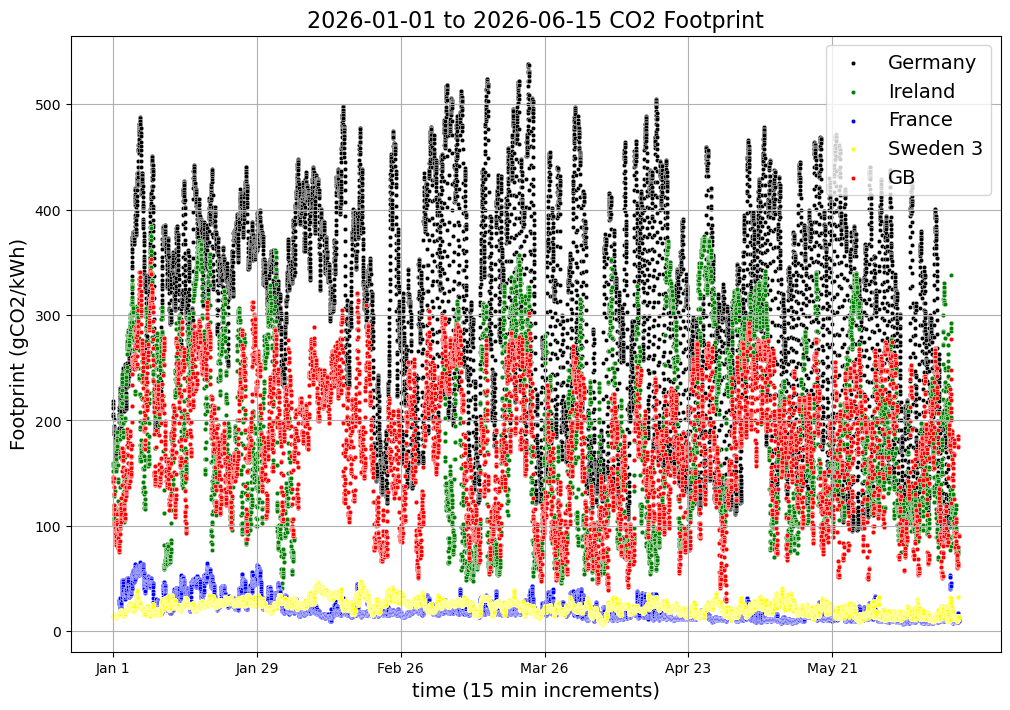

CPU times: user 6.96 s, sys: 221 ms, total: 7.18 s
Wall time: 7.31 s


In [90]:
%%time
# combine into single plot
# help for legend from https://stackoverflow.com/questions/5484922/secondary-axis-with-twinx-how-to-add-to-legend

s = 10

fig, ax1 = plt.subplots(figsize=(12,8)) # initializes figure and plots

sns.scatterplot(data=df_DE, x='datetime', y='footprint (gCO2/kWh)', color='black', ax=ax1, label='Germany', s=s)
sns.scatterplot(data=df_IE, x='datetime', y='footprint (gCO2/kWh)', color='green', ax=ax1, label='Ireland', s=s)
sns.scatterplot(data=df_FR, x='datetime', y='footprint (gCO2/kWh)', color='blue', ax=ax1, label='France', s=s)
sns.scatterplot(data=df_SE3, x='datetime', y='footprint (gCO2/kWh)', color='yellow', ax=ax1, label='Sweden 3', s=s)
sns.scatterplot(data=df_GB, x='datetime', y='footprint (gCO2/kWh)', color='red', ax=ax1, label='GB', s=s)


ax1.legend(fontsize=14)
ax1.grid()

ax1.set_xlabel('time (15 min increments)', fontsize=14)
ax1.set_ylabel('Footprint (gCO2/kWh)', fontsize=14)

ax1.set_xticks(np.arange(0,(365/2-15)*96,96*28))
#plt.xticks(rotation='vertical')
ax1.set_xticklabels(['Jan 1', 'Jan 29', 'Feb 26', 'Mar 26', 'Apr 23','May 21'])
# plt.legend()
plt.title("2026-01-01 to 2026-06-15 CO2 Footprint", fontsize=16)

plt.show()

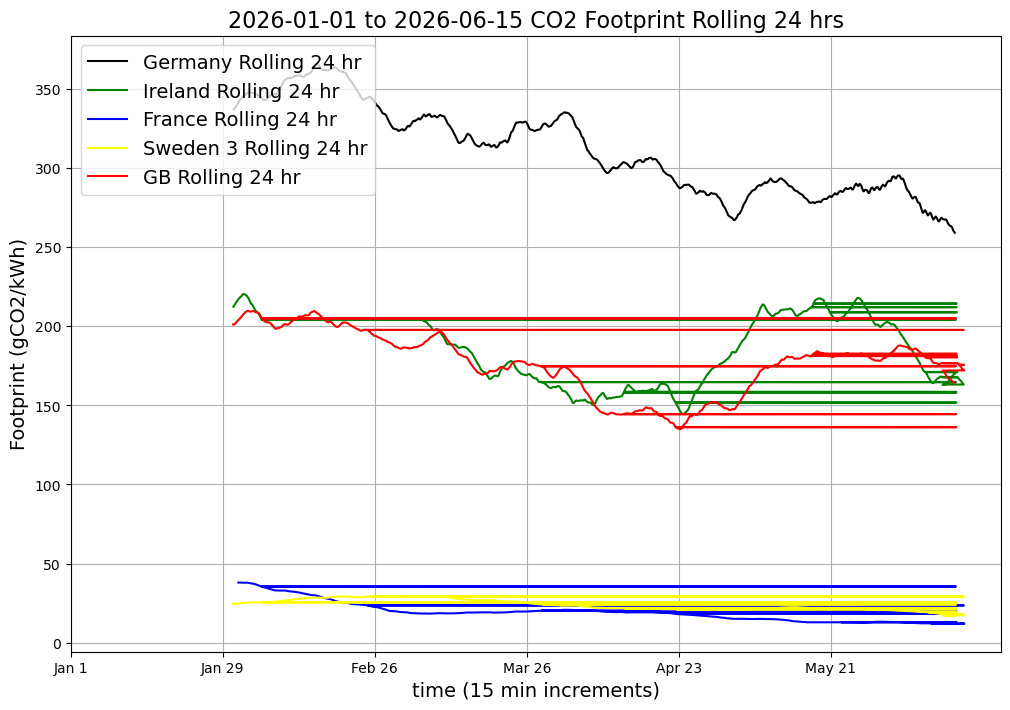

CPU times: user 2.11 s, sys: 37.3 ms, total: 2.14 s
Wall time: 2.17 s


In [98]:
%%time
# combine into single plot

fig, ax1 = plt.subplots(figsize=(12,8)) # initializes figure and plots

#sns.lineplot(data=df_DE, x='datetime', y='footprint (gCO2/kWh)', color='black', ax=ax1, label='Germany')
ax1.plot(df_DE['datetime'], df_DE['footprint (gCO2/kWh)'].rolling(window=96*30, min_periods=96*30).mean(), color='black', label='Germany Rolling 24 hr')
#sns.lineplot(data=df_IE, x='datetime', y='footprint (gCO2/kWh)', color='green', ax=ax1, label='Ireland')
ax1.plot(df_IE['datetime'], df_IE['footprint (gCO2/kWh)'].rolling(window=96*30, min_periods=96*30).mean(), color='green',label='Ireland Rolling 24 hr')
#sns.lineplot(data=df_FR, x='datetime', y='footprint (gCO2/kWh)', color='blue', ax=ax1, label='France')
ax1.plot(df_FR['datetime'], df_FR['footprint (gCO2/kWh)'].rolling(window=96*30, min_periods=96*30).mean(), color='blue',label='France Rolling 24 hr')
#sns.lineplot(data=df_SE3, x='datetime', y='footprint (gCO2/kWh)', color='yellow', ax=ax1, label='Sweden 3')
ax1.plot(df_SE3['datetime'], df_SE3['footprint (gCO2/kWh)'].rolling(window=96*30, min_periods=96*30).mean(), color='yellow',label='Sweden 3 Rolling 24 hr')
#sns.lineplot(data=df_GB, x='datetime', y='footprint (gCO2/kWh)', color='red', ax=ax1, label='GB')
ax1.plot(df_GB['datetime'], df_GB['footprint (gCO2/kWh)'].rolling(window=96*30, min_periods=96*30).mean(), color='red',label='GB Rolling 24 hr')


ax1.legend(fontsize=14)
ax1.grid()

ax1.set_xlabel('time (15 min increments)', fontsize=14)
ax1.set_ylabel('Footprint (gCO2/kWh)', fontsize=14)

ax1.set_xticks(np.arange(0,(365/2-15)*96,96*28))
#plt.xticks(rotation='vertical')
ax1.set_xticklabels(['Jan 1', 'Jan 29', 'Feb 26', 'Mar 26', 'Apr 23','May 21'])
# plt.legend()
plt.title("2026-01-01 to 2026-06-15 CO2 Footprint Rolling 24 hrs", fontsize=16)

plt.show()


# plt.plot(df["A"].rolling(window=2, min_periods=1).mean(), label="Rolling Mean (2)")